Models loaded successfully.
Noise std (scaled): AMOC=0.0391, PD=0.0315, SFWF=0.0766


Rolling forecast w/ noise: 100%|██████████| 31592/31592 [03:08<00:00, 167.88it/s]


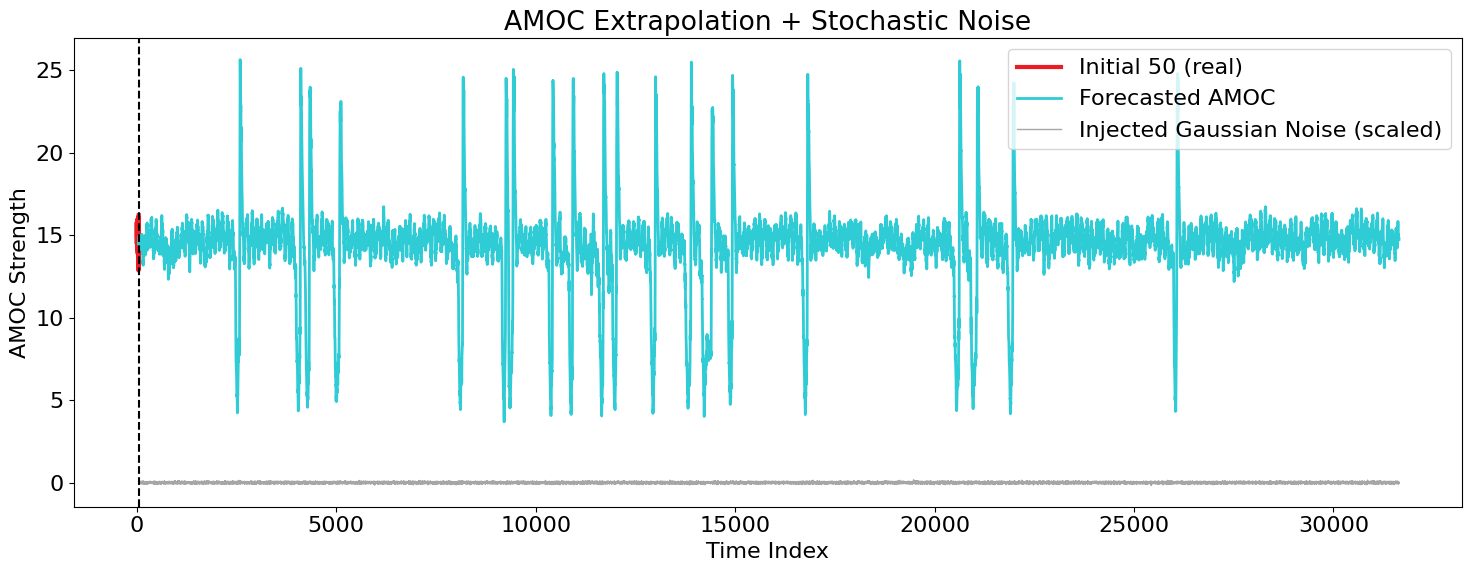

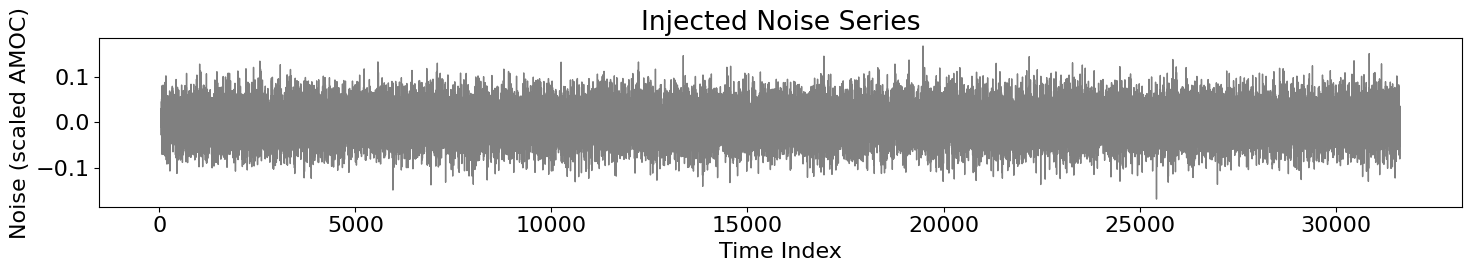

In [1]:
# You can try only perturb SFWF
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

plt.rcParams.update({'font.size': 16})


# Custom loss function, but MSE error works as well
def sign_integral_loss(y_true, y_pred):
    y_true_diff = y_true[:, 1:] - y_true[:, :-1]
    y_pred_diff = y_pred[:, 1:] - y_pred[:, :-1]

    sigma_threshold = 2 * K.std(y_true_diff)
    abrupt_events = K.cast(K.abs(y_true_diff) > sigma_threshold, K.floatx())

    sign_penalty = K.mean(K.abs(K.sign(y_true_diff) - K.sign(y_pred_diff)) * abrupt_events)

    integral_true = K.cumsum(y_true, axis=1)
    integral_pred = K.cumsum(y_pred, axis=1)
    integral_penalty = K.mean(K.square(integral_true - integral_pred))

    y_true_accel = y_true_diff[:, 1:] - y_true_diff[:, :-1]
    y_pred_accel = y_pred_diff[:, 1:] - y_pred_diff[:, :-1]
    smoothness_penalty = K.mean(K.abs(y_true_accel - y_pred_accel))

    return K.mean(K.square(y_true - y_pred)) + 10*sign_penalty + 5*integral_penalty + 2*smoothness_penalty


file_path = 'CombinedDatasetLongUnsmooth.csv'
df = pd.read_csv(file_path)[['AMOC_40N', 'PD_200m', 'SFWF']]

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)

window_size = 50
forecast_horizon = 13


# Build Sliding Windows
def create_windows(data, target_idx, window_size, forecast_horizon):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + forecast_horizon, target_idx])
    return np.array(X), np.array(y).reshape(-1, 1)

X_amoc, y_amoc = create_windows(data_scaled, 0, window_size, forecast_horizon)
X_pd,   y_pd   = create_windows(data_scaled, 1, window_size, forecast_horizon)
X_sfwf, y_sfwf = create_windows(data_scaled, 2, window_size, forecast_horizon)

# Test split
split = int(0.8 * len(X_amoc))
X_test_amoc, y_test_amoc = X_amoc[split:], y_amoc[split:]
X_test_pd,   y_test_pd   = X_pd[split:],   y_pd[split:]
X_test_sfwf, y_test_sfwf = X_sfwf[split:], y_sfwf[split:]


# Load Models
# Use your own ML models there, like ESN, CNN, LSTM, RNN ...
loaded_model_amoc = load_model("cnn_model_amoc.h5", custom_objects={"sign_integral_loss": sign_integral_loss})
loaded_model_pd   = load_model("cnn_model_pd.h5",   custom_objects={"sign_integral_loss": sign_integral_loss})
loaded_model_sfwf = load_model("cnn_model_sfwf.h5", custom_objects={"sign_integral_loss": sign_integral_loss})
print("Models loaded successfully.")


# Compute Noise STD (Residual)
# You can also try to get the noise by moving average
y_pred_amoc_test = loaded_model_amoc.predict(X_test_amoc, verbose=0).flatten()
y_pred_pd_test   = loaded_model_pd.predict(X_test_pd, verbose=0).flatten()
y_pred_sfwf_test = loaded_model_sfwf.predict(X_test_sfwf, verbose=0).flatten()

resid_amoc = y_test_amoc.flatten() - y_pred_amoc_test
resid_pd   = y_test_pd.flatten()   - y_pred_pd_test
resid_sfwf = y_test_sfwf.flatten() - y_pred_sfwf_test

noise_std_amoc = np.std(resid_amoc)
noise_std_pd   = np.std(resid_pd)
noise_std_sfwf = np.std(resid_sfwf)

print(f"Noise std (scaled): AMOC={noise_std_amoc:.4f}, PD={noise_std_pd:.4f}, SFWF={noise_std_sfwf:.4f}")


# Initialize Stochastic Forecast
initial_window = X_test_amoc[-1].copy()
current_window = initial_window[np.newaxis, :, :]

evolve_steps = 31592
predicted_sequence = []
noise_amoc_used = []  # <-- correct noise tracking


@tf.function(reduce_retracing=True)
def step_predict(input_window):
    return (
        loaded_model_amoc(input_window, training=False),
        loaded_model_pd(input_window,   training=False),
        loaded_model_sfwf(input_window, training=False)
    )


# Rolling Forecast w/ Gaussian Noise
for step in tqdm(range(evolve_steps), desc="Rolling forecast w/ noise"):
    amoc_pred, pd_pred, sfwf_pred = step_predict(current_window)

    # Draw noise (scaled space)
    na  = np.random.normal(0, noise_std_amoc)
    npd = np.random.normal(0, noise_std_pd)
    ns  = np.random.normal(0, noise_std_sfwf)

    noise_amoc_used.append(na)

    nxt = np.array([
        amoc_pred[0, 0].numpy(), #+ na,
        pd_pred[0, 0].numpy(),   #+ npd,
        sfwf_pred[0, 0].numpy() + 1*ns    # You can try to modify the noise multiplier
    ])

    predicted_sequence.append(nxt)

    current_window = np.roll(current_window, -1, axis=1)
    current_window[0, -1, :] = nxt

predicted_sequence = np.array(predicted_sequence)
noise_amoc_used = np.array(noise_amoc_used)

predicted_inv = scaler.inverse_transform(predicted_sequence)



# Last 50 real points (unscaled)
initial_window_inv = df[['AMOC_40N', 'PD_200m', 'SFWF']].values[-window_size:]

time_initial = np.arange(window_size)
time_future  = np.arange(window_size, window_size + evolve_steps)

pred_amoc = predicted_inv[:, 0]
noise_used = noise_amoc_used  # in scaled units, like original example


# 1) AMOC + Noise
fig, ax = plt.subplots(figsize=(15,6))

ax.plot(time_initial, initial_window_inv[:,0],
        color="#ED1B23", lw=3, label="Initial 50 (real)")

ax.plot(time_future, pred_amoc,
        color="#2fccd6", lw=2, label="Forecasted AMOC")

ax.plot(time_future, noise_used,
        color="gray", lw=1, alpha=0.7, label="Injected Gaussian Noise (scaled)")

ax.axvline(time_initial[-1], linestyle="--", color="black")

ax.set_xlabel("Time Index")
ax.set_ylabel("AMOC Strength")
ax.set_title("AMOC Extrapolation + Stochastic Noise")
ax.legend()
ax.grid(False)

plt.tight_layout()
plt.show()


# 2) Noise-only plot
fig2, ax2 = plt.subplots(figsize=(15,3))
ax2.plot(time_future, noise_used, color="gray", lw=1)
ax2.set_xlabel("Time Index")
ax2.set_ylabel("Noise (scaled AMOC)")
ax2.set_title("Injected Noise Series")
ax2.grid(False)
plt.tight_layout()
plt.show()

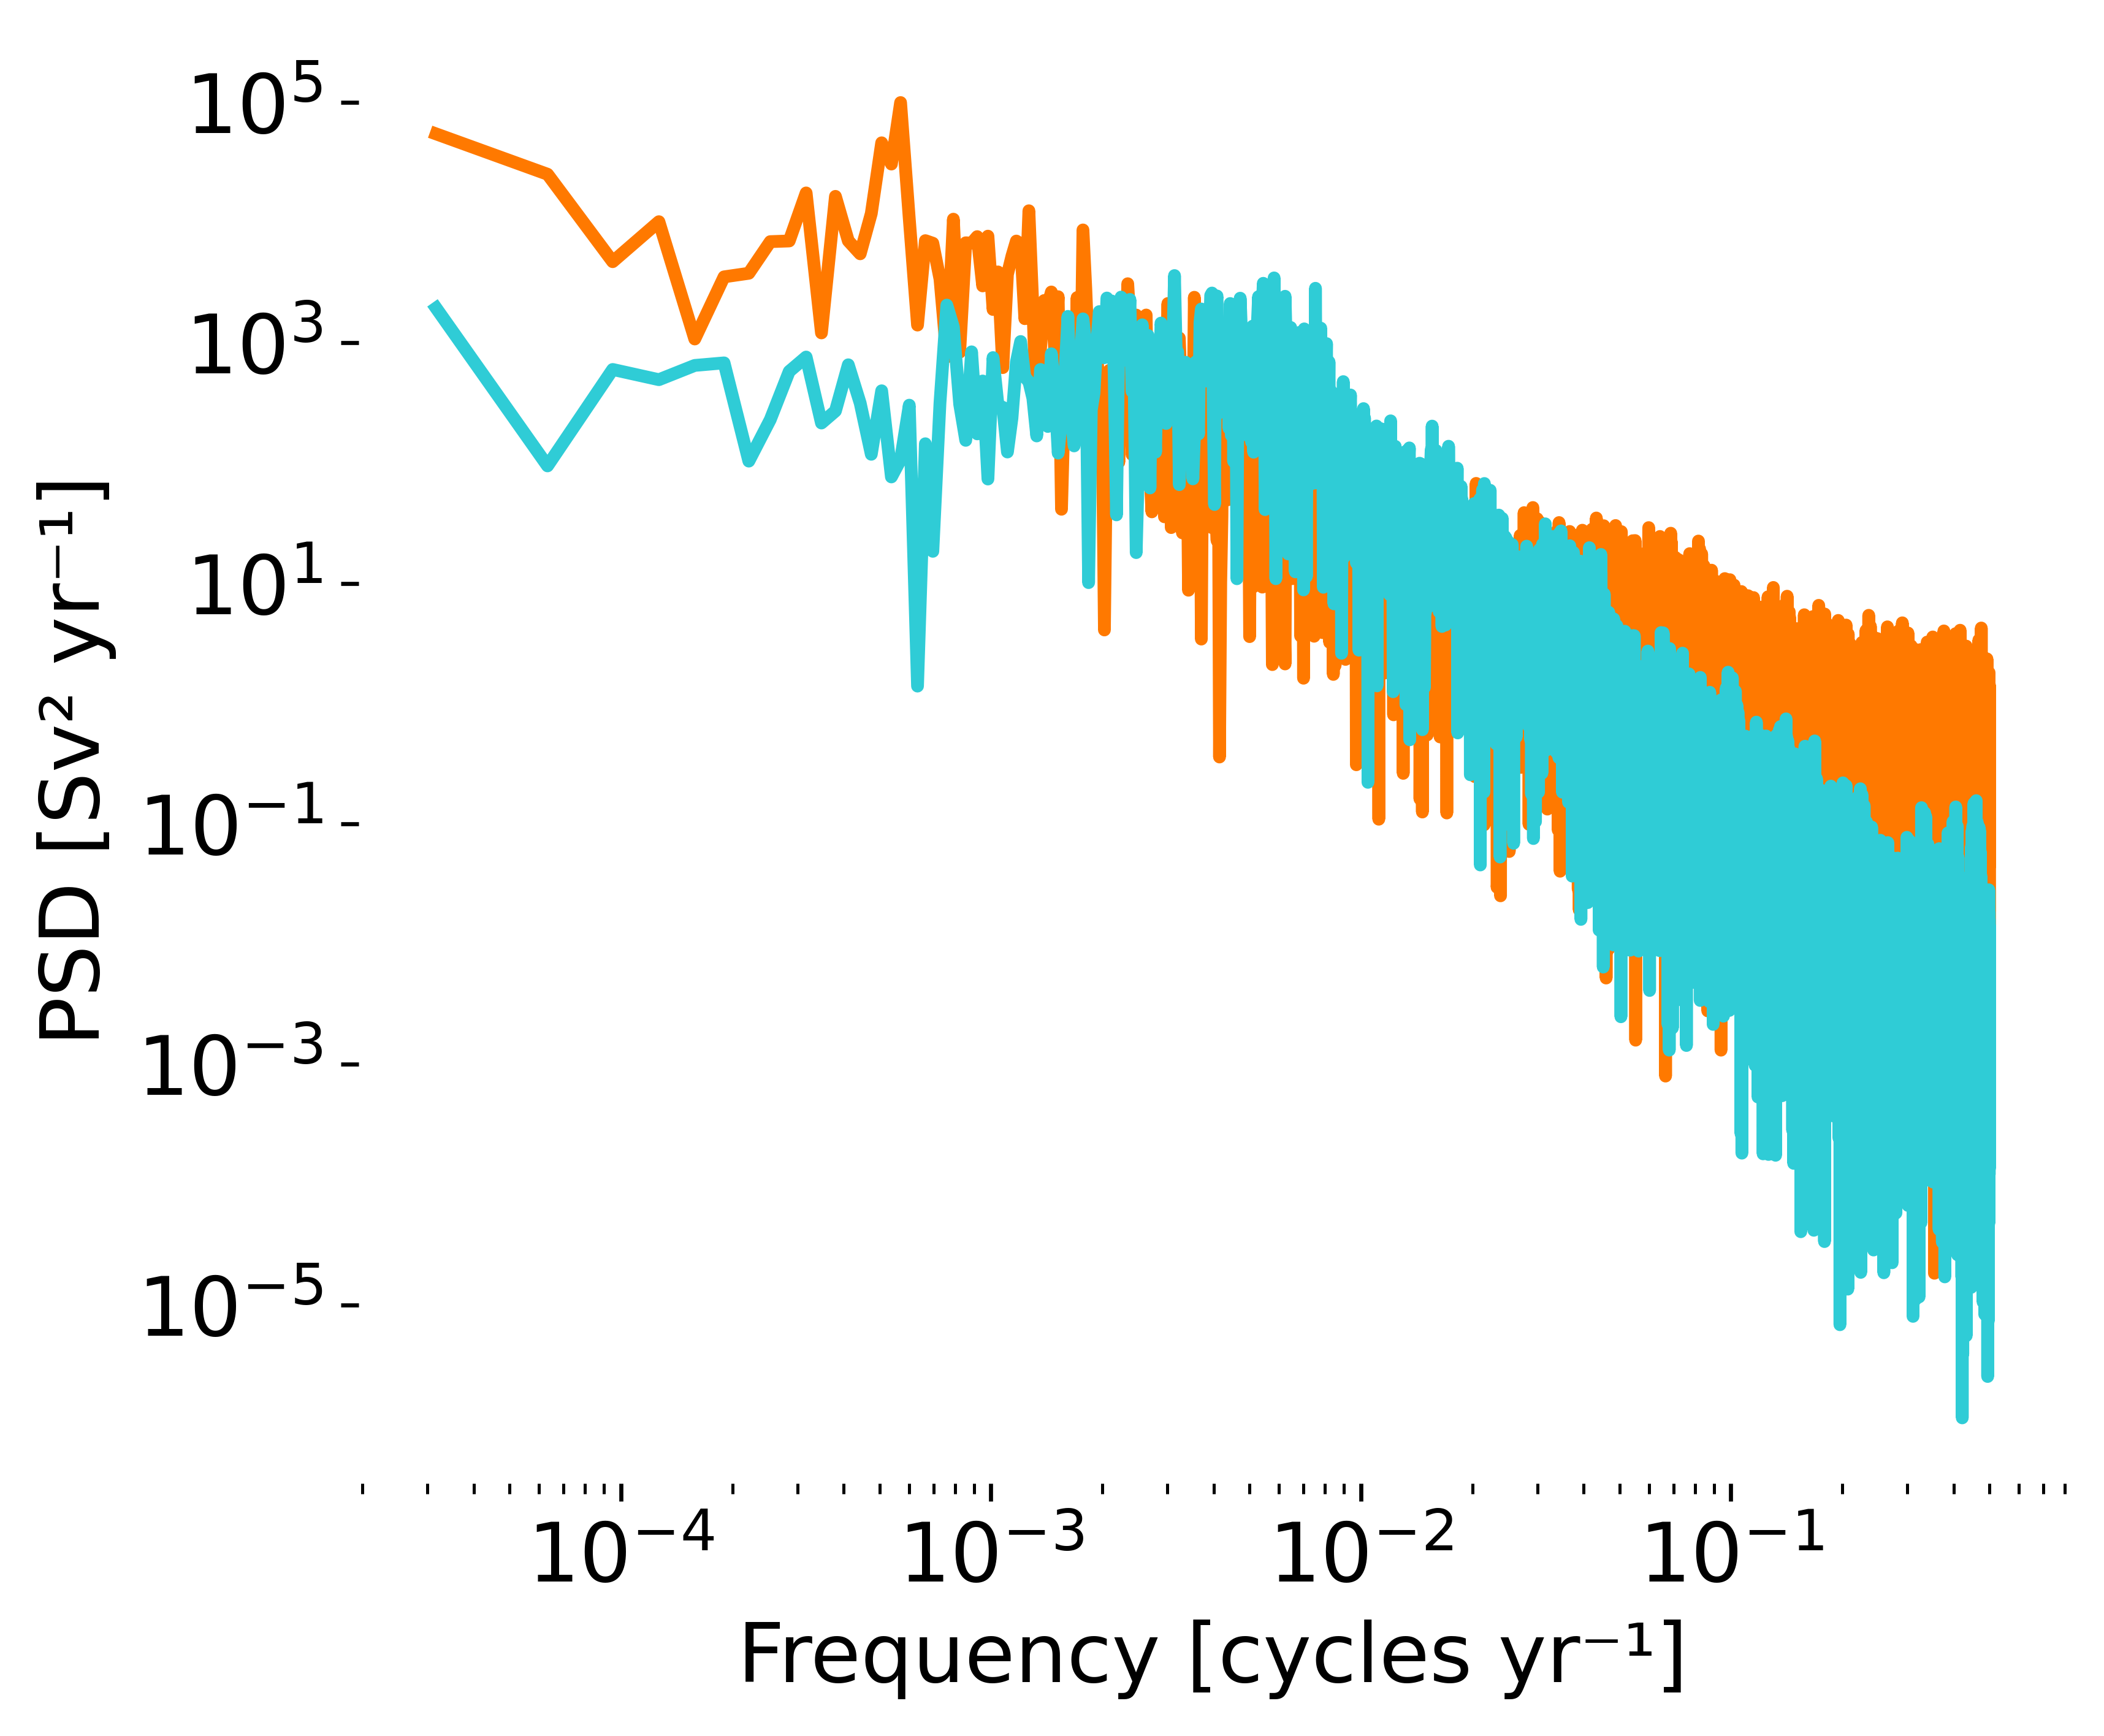

In [2]:
# AMOC Power Spectral Density — CESM vs Simulation
# Match length if needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_power_spectrum(series, fs=1.0):
    """Compute single-sided, variance-preserving power spectral density."""
    x = np.asarray(series, dtype=np.float64)
    x = x - np.mean(x)
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, d=1.0/fs)
    psd = (np.abs(X)**2) / (N * fs)
    psd[1:-1] *= 2.0  # single-sided correction
    return freqs[1:], psd[1:]  # skip DC component

FS = 1.0  # 1 sample per year (or per time step)
csv_path = "CombinedDatasetLongUnsmooth.csv"

df_full = pd.read_csv(csv_path)
df_full.columns = df_full.columns.str.strip().str.replace(" ", "_")
full_amoc_series = df_full["AMOC_40N"].dropna().values

# Match CESM vs Simulation lengths
forecast_amoc_series = predicted_inv[:, 0]
N_fore = len(forecast_amoc_series)
N_true = len(full_amoc_series)

if N_true >= N_fore:
    true_amoc_series = full_amoc_series[:N_fore]
else:
    forecast_amoc_series = forecast_amoc_series[:N_true]
    true_amoc_series = full_amoc_series

# Compute PSDs
freq_true, psd_true = compute_power_spectrum(true_amoc_series, fs=FS)
freq_fore, psd_fore = compute_power_spectrum(forecast_amoc_series, fs=FS)


fig, ax = plt.subplots(figsize=(6, 5), dpi=600)

ax.loglog(freq_true, psd_true, color="#FF7900", lw=2.5)

# Simulation (CNN + noise)
ax.loglog(freq_fore, psd_fore, color="#2fccd6", lw=2.5)

# Axis labels
ax.set_xlabel("Frequency [cycles yr⁻¹]")
ax.set_ylabel("PSD [Sv² yr⁻¹]")

ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

fig.patch.set_alpha(0)
ax.patch.set_alpha(0)

plt.tight_layout()
plt.show()

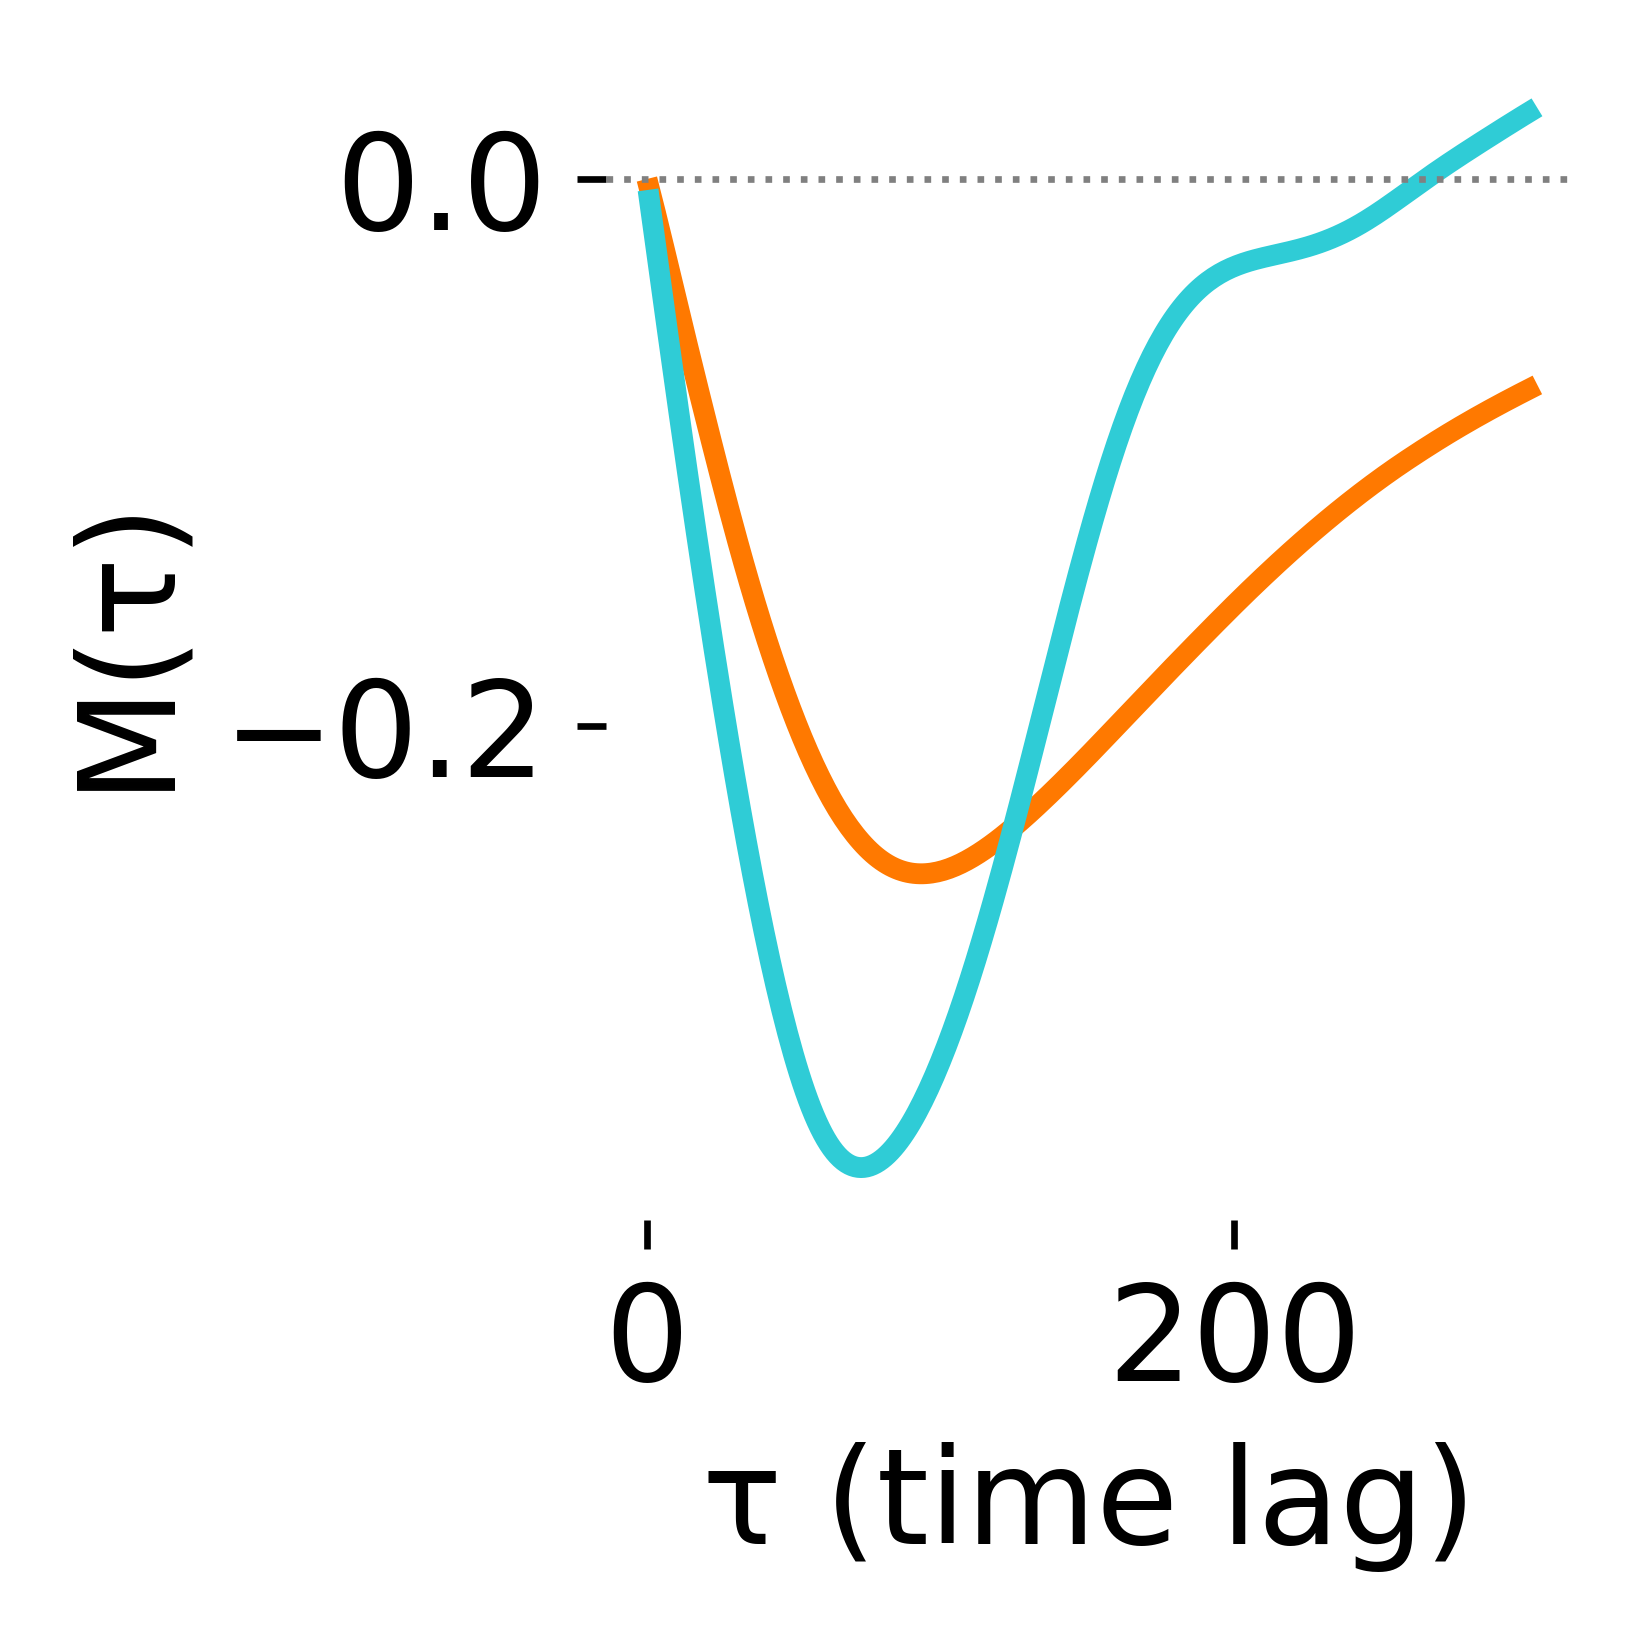

In [3]:
# Time-Reversal Asymmetry M(τ) — CESM vs Simulation (AMOC)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ma_centered(x, w=60):
    """Centered moving average."""
    return pd.Series(np.asarray(x), dtype=float).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

def M_curve(x, tau_max=300):
    """Compute time-reversal asymmetry curve M(τ)."""
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    n = x.size
    if n <= 1:
        return np.arange(0), np.array([])
    tmax = int(min(tau_max, n - 1))
    taus = np.arange(1, tmax + 1)
    M = np.empty_like(taus, dtype=float)
    for i, tau in enumerate(taus):
        d = x[:-tau] - x[tau:]
        d = d[np.isfinite(d)]
        if d.size == 0:
            M[i] = np.nan
            continue
        mu2 = np.mean(d*d)
        mu3 = np.mean(d*d*d)
        M[i] = mu3 / (mu2 + 1e-12)
    return taus, M

def normalize_01(x):
    x = np.asarray(x, float)
    xmin, xmax = np.nanmin(x), np.nanmax(x)
    rng = xmax - xmin if xmax > xmin else 1.0
    return (x - xmin) / rng

csv_path = "CombinedDatasetLongUnsmooth.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip().str.replace(" ", "_")
amoc_true = df["AMOC_40N"].dropna().values

amoc_forecast = predicted_inv[:, 0]

# Match lengths
target_len = min(len(amoc_true), len(amoc_forecast))
amoc_true = amoc_true[:target_len]
amoc_forecast = amoc_forecast[:target_len]

amoc_true_n = normalize_01(ma_centered(amoc_true, w=60))
amoc_forecast_n = normalize_01(ma_centered(amoc_forecast, w=60))

# Compute M(τ)
tau_max = min(300, target_len - 1)
taus_true, M_true = M_curve(amoc_true_n, tau_max=tau_max)
taus_fore, M_fore = M_curve(amoc_forecast_n, tau_max=tau_max)

fig, ax = plt.subplots(figsize=(3, 3), dpi=600)

# CESM (true)
ax.plot(taus_true, M_true, color="#FF7900", lw=2.5)

# Simulation (CNN + noise)
ax.plot(taus_fore, M_fore, color="#2fccd6", lw=2.5)

# Axis labels
ax.set_xlabel("τ (time lag)")
ax.set_ylabel("M(τ)")

ax.axhline(0, color="gray", lw=0.8, ls=":")
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# Transparent background
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
plt.tight_layout()
plt.show()

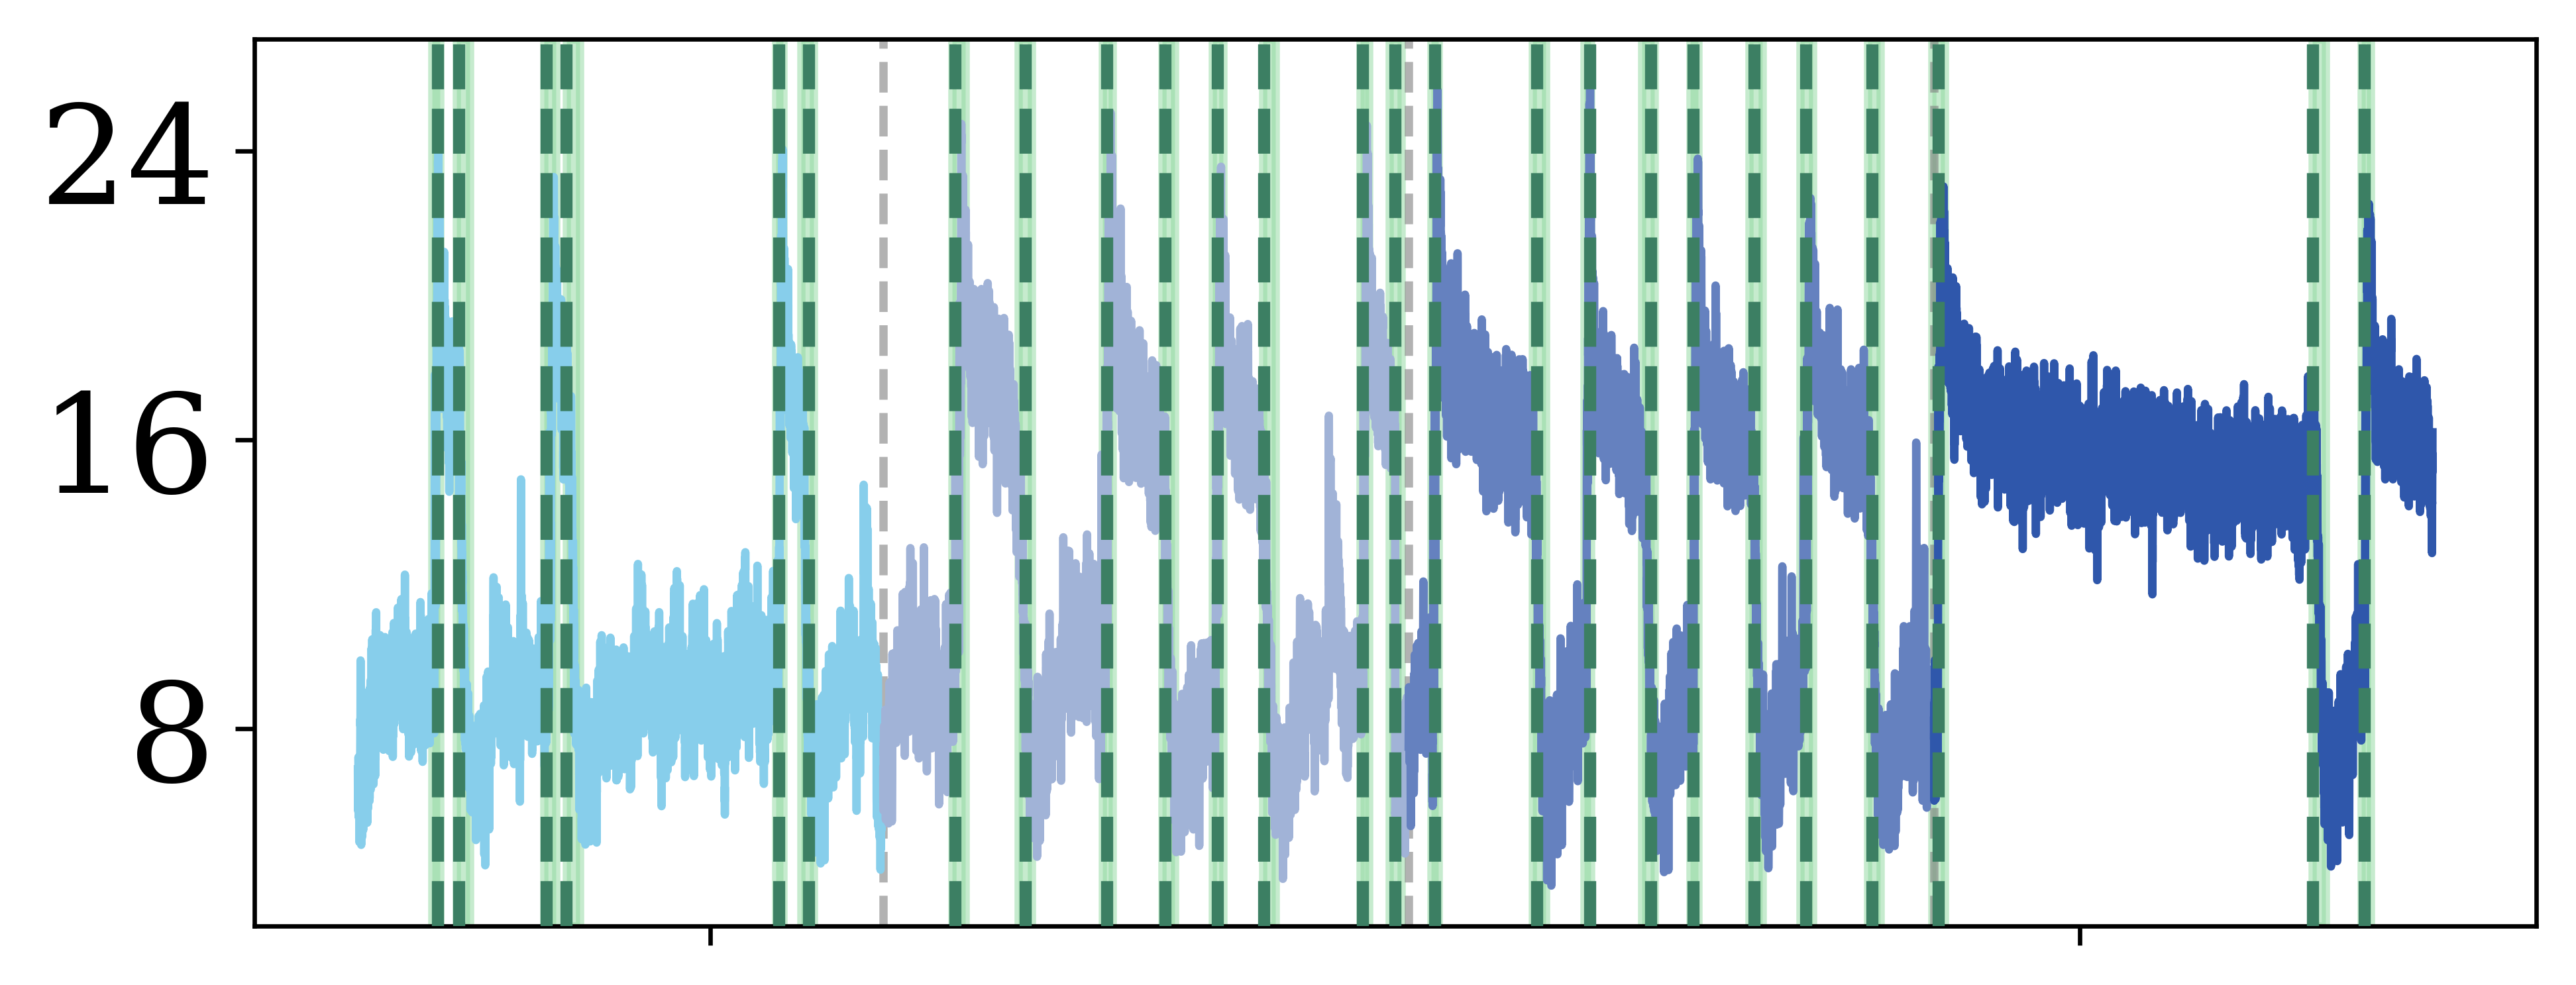

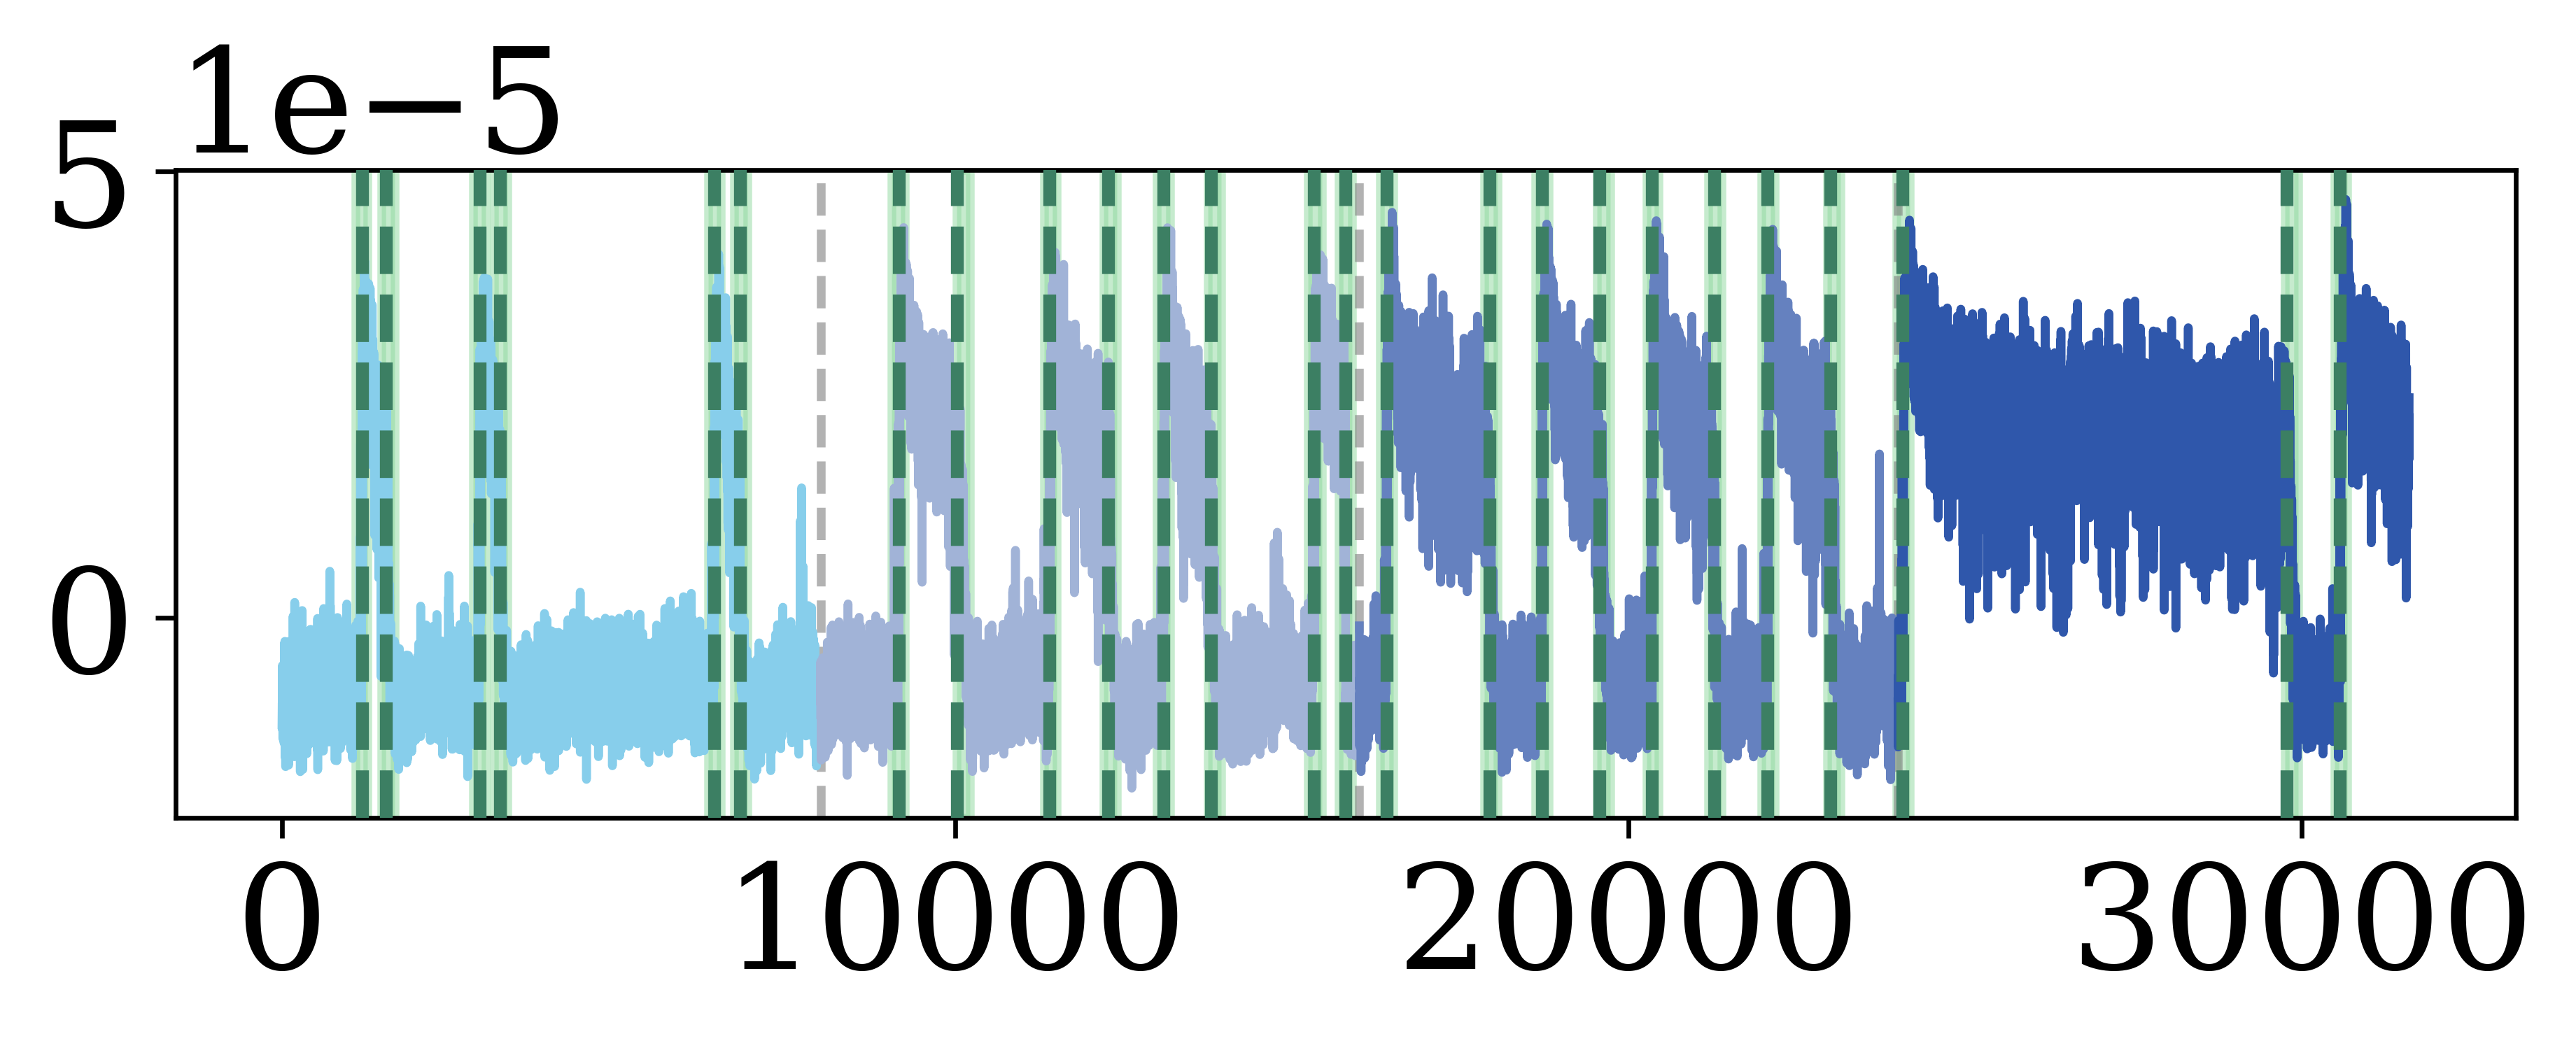

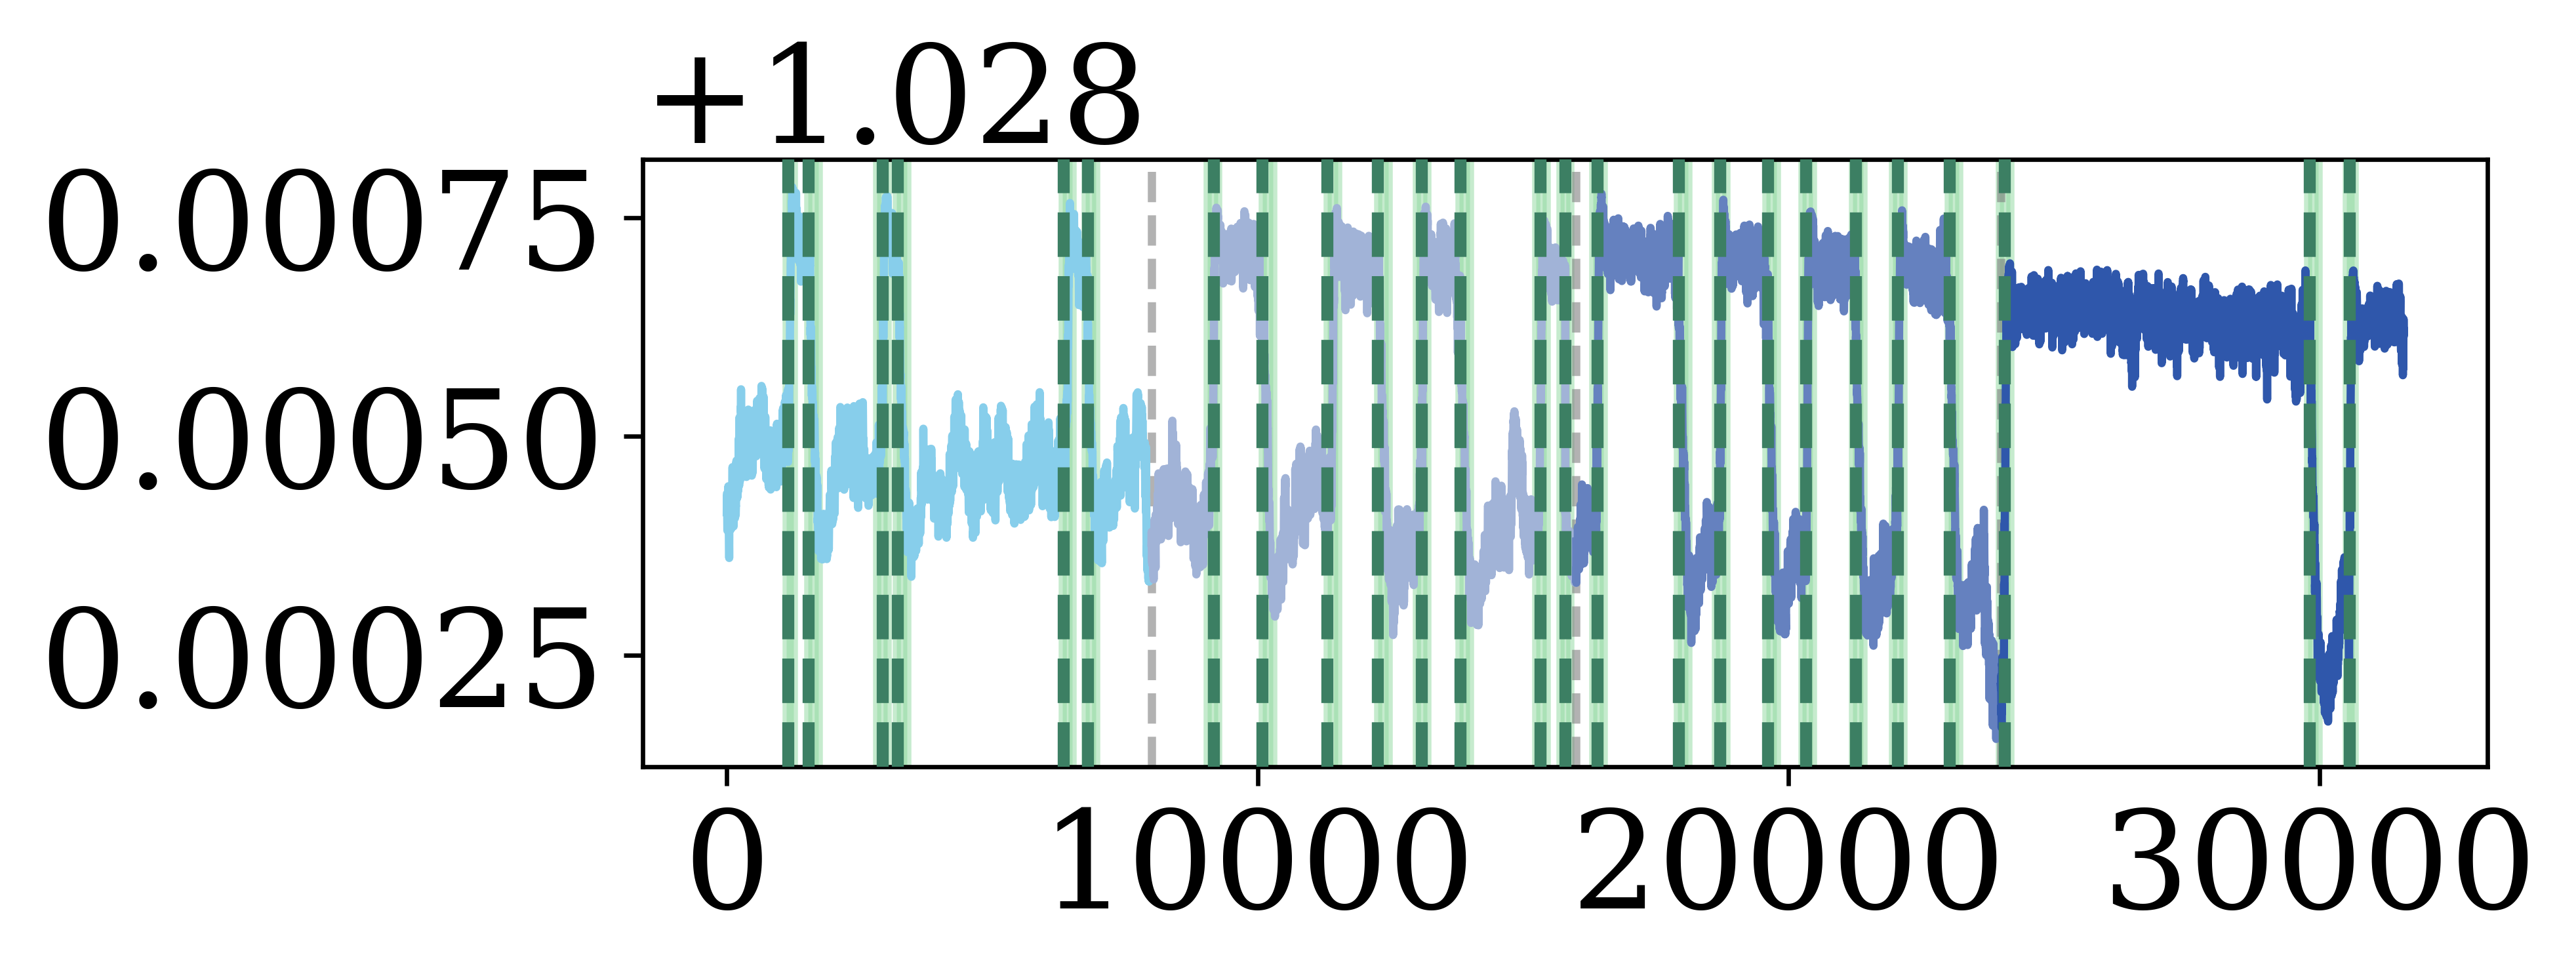

In [4]:
#  Plot AMOC_40N, SFWF, PD_200m with Ramp-Fit Shading + ONE Abrupt Jump per Shade
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Computer Modern Roman'],
    'font.size': 24,
    'axes.facecolor': 'none',
    'figure.facecolor': 'none'
})
plt.rcParams.update({
    'font.size': 24,
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'axes.titlesize': 16,
    'axes.labelsize': 25,
    'xtick.labelsize': 25,
    'ytick.labelsize': 25,
    'legend.fontsize': 16
})

df = pd.read_csv("CombinedDatasetLongUnsmooth.csv")
df.columns = df.columns.str.strip().str.replace(" ", "_")

amoc_raw = df["AMOC_40N"].dropna().values
sfwf_raw = df["SFWF"].dropna().values
pd_raw   = df["PD_200m"].dropna().values

N = min(len(amoc_raw), len(sfwf_raw), len(pd_raw))
amoc_raw, sfwf_raw, pd_raw = amoc_raw[:N], sfwf_raw[:N], pd_raw[:N]
time = np.arange(N)

sesame_grey = ["skyblue", "#A1B3D7", "#6581BF", "#2F57AB"]
cmap = LinearSegmentedColormap.from_list("sesame_grey", sesame_grey)
segments = N // 8000 + 1
colors = cmap(np.linspace(0, 1, segments))

# Load ramp-fitting regions (shading only)
ramp_csv_path = "/content/ramp_fit_results_AMOC_SFWF_PD.csv"
ramp_df = pd.read_csv(ramp_csv_path)

required_cols = {"Variable", "t0", "t1"}
if not required_cols.issubset(ramp_df.columns):
    raise ValueError(f"The ramp-fitting CSV must contain columns: {required_cols}")

# Largest jump finder
def largest_jump_in_window(series, start, end):
    dx = np.diff(series[start:end])
    if len(dx) == 0:
        return None
    local_idx = np.argmax(np.abs(dx))
    return start + local_idx + 1

def plot_variable(var_name, y, ylabel, save_name=None, yticks=None, two_xticks=False):
    fig, ax = plt.subplots(figsize=(7, 3), dpi=600)
    fig.patch.set_alpha(0)

    # Ramp-fit shaded regions + one abrupt jump per shade
    for _, row in ramp_df[ramp_df["Variable"] == var_name].iterrows():
        ax.axvspan(
            row.t0, row.t1,
            facecolor="#8FD89F",
            edgecolor="#8FD89F",
            alpha=0.5,
            lw=1.5,
            zorder=0
        )

        abrupt_idx = largest_jump_in_window(y, int(row.t0), int(row.t1))

        if abrupt_idx is not None:
            ax.axvline(
                abrupt_idx,
                color="#3C7F63",
                linestyle="--",
                linewidth=2.2,
                alpha=1.0,
                zorder=3
            )

    for i in range(segments):
        start = i * 8000
        end = min((i + 1) * 8000, N)

        ax.plot(time[start:end], y[start:end],
                color=colors[i], lw=1.5, zorder=2)

        if i > 0:
            ax.axvline(start, color="grey", linestyle="--", alpha=0.6, zorder=1)

    if yticks is not None:
        ax.set_yticks(yticks)
        ax.set_yticklabels([str(t) for t in yticks])

    if two_xticks:
        xmin, xmax = ax.get_xlim()
        tick1 = xmin + 0.2 * (xmax - xmin)
        tick2 = xmin + 0.8 * (xmax - xmin)
        ax.set_xticks([tick1, tick2])
        ax.set_xticklabels(["", ""])  # empty (or change if needed)

    plt.tight_layout()

    if save_name:
        plt.savefig(save_name, dpi=600, transparent=True, bbox_inches='tight')
    plt.show()


plot_variable("AMOC_40N", amoc_raw, "AMOC_40N [Sv]",
              "AMOC_40N_transparent.png",
              yticks=[8, 16, 24],
              two_xticks=True)     # ← ONLY CHANGE FOR X-TICKS

plot_variable("SFWF", sfwf_raw, "SFWF [kg/m²/s]",
              "SFWF_transparent.png")

plot_variable("PD_200m", pd_raw, "PD_200m [g/cm³]",
              "PD_200m_transparent.png")


Model noise std (AMOC): 0.04211458395130526
Model noise std (PD): 0.036314586622958556
Model noise std (SFWF scaled): 0.07861458202887225
Model noise std (SFWF real): 5.180786854751505e-06
Low-state noise : 1.9033582898711405e-09 2.9940575428633034e-06
High-state noise: 4.0973402145583683e-08 4.121083231824428e-06


MC:   0%|          | 0/50 [00:00<?, ?it/s]

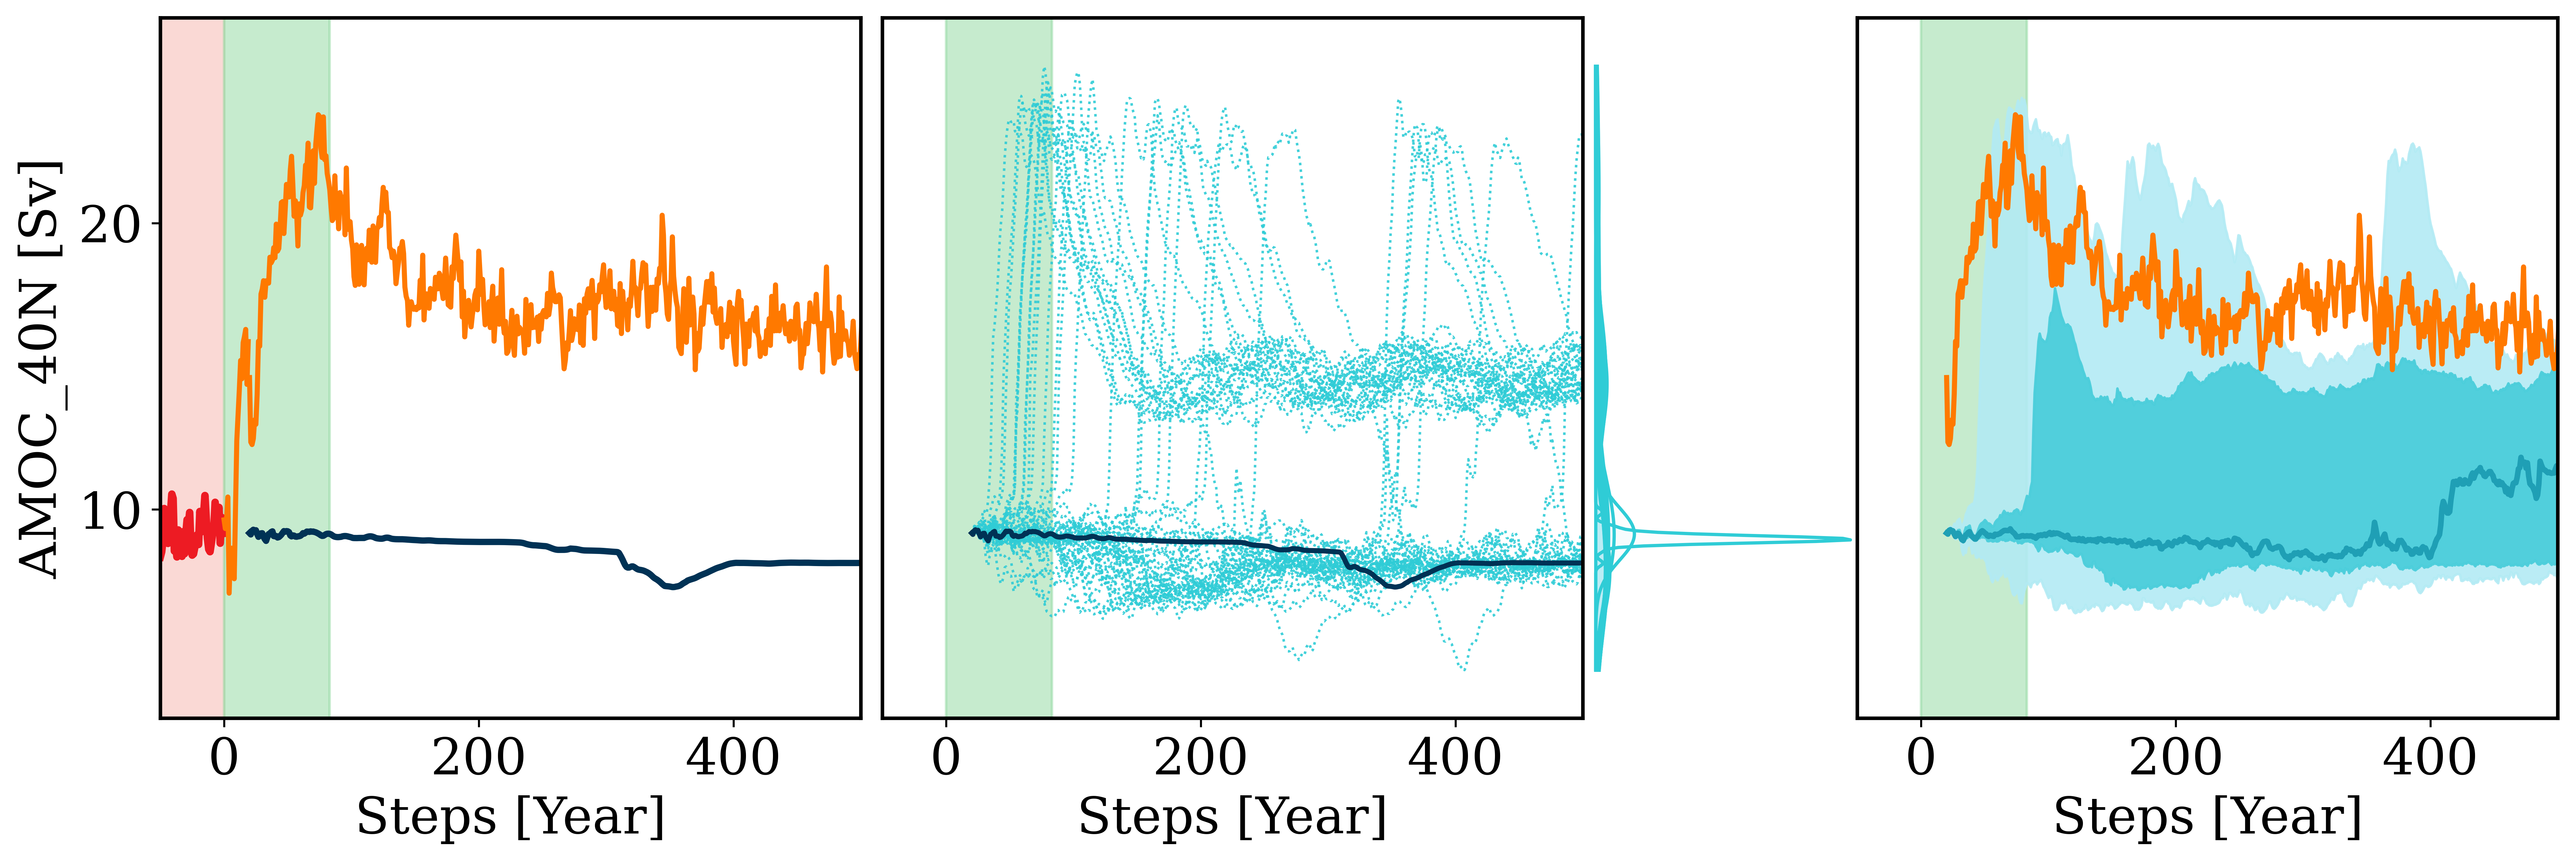

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter1d
from tqdm.notebook import tqdm
from matplotlib.ticker import MaxNLocator
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

# STYLE
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif', 'Computer Modern Roman'],
    'text.color': '#000000',
    'axes.labelcolor': '#000000',
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'figure.facecolor': (0, 0, 0, 0),
    'axes.facecolor': (0, 0, 0, 0),
    'savefig.facecolor': (0, 0, 0, 0),
})

# SETTINGS
DATA_FILE = "CombinedDatasetLongUnsmooth.csv"
RAMP_FILE = "/content/ramp_fit_results_AMOC_SFWF_PD.csv"

MODEL_AMOC = "cnn_model_amoc.h5"
MODEL_PD   = "cnn_model_pd.h5"
MODEL_SFWF = "cnn_model_sfwf.h5"

window_size = 50
forecast_horizon = 20

MC_RUNS = 50
STEPS = 500
START_IDX = 20330
WINDOW = window_size

LOW_ENTER = 11
LOW_EXIT  = 13

SMOOTH_WINDOW = 10
SMOOTH_POLY   = 3

# CUSTOM LOSS (or your own loss such as MSE, RMSE, R2, ...)
def sign_integral_loss(y_true, y_pred):
    y_true_diff = y_true[:, 1:] - y_true[:, :-1]
    y_pred_diff = y_pred[:, 1:] - y_pred[:, :-1]

    sigma_threshold = 2 * K.std(y_true_diff)
    abrupt_events = K.cast(K.abs(y_true_diff) > sigma_threshold, K.floatx())

    sign_penalty = K.mean(K.abs(K.sign(y_true_diff) - K.sign(y_pred_diff)) * abrupt_events)

    integral_true = K.cumsum(y_true, axis=1)
    integral_pred = K.cumsum(y_pred, axis=1)
    integral_penalty = K.mean(K.square(integral_true - integral_pred))

    y_true_accel = y_true_diff[:, 1:] - y_true_diff[:, :-1]
    y_pred_accel = y_pred_diff[:, 1:] - y_pred_diff[:, :-1]
    smoothness_penalty = K.mean(K.abs(y_true_accel - y_pred_accel))

    return (
        K.mean(K.square(y_true - y_pred))
        + 10 * sign_penalty
        + 5 * integral_penalty
        + 2 * smoothness_penalty
    )


if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(f"Missing data file: {DATA_FILE}")

df_full = pd.read_csv(DATA_FILE)
df_full.columns = df_full.columns.str.strip().str.replace(" ", "_", regex=False)

if not os.path.exists(RAMP_FILE):
    raise FileNotFoundError(f"Missing ramp file: {RAMP_FILE}")

ramp_df = pd.read_csv(RAMP_FILE)
ramp_df.columns = ramp_df.columns.str.strip()

df = df_full[['AMOC_40N', 'PD_200m', 'SFWF']].copy()

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)


def create_windows(data, target_idx):
    X, y = [], []
    for i in range(len(data) - window_size - forecast_horizon):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size + forecast_horizon, target_idx])
    return np.array(X), np.array(y).reshape(-1, 1)

X_amoc, y_amoc = create_windows(data_scaled, 0)
X_pd,   y_pd   = create_windows(data_scaled, 1)
X_sfwf, y_sfwf = create_windows(data_scaled, 2)

split = int(0.8 * len(X_amoc))


for model_path in [MODEL_AMOC, MODEL_PD, MODEL_SFWF]:
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Missing model file: {model_path}")

loaded_model_amoc = load_model(MODEL_AMOC, custom_objects={"sign_integral_loss": sign_integral_loss})
loaded_model_pd   = load_model(MODEL_PD,   custom_objects={"sign_integral_loss": sign_integral_loss})
loaded_model_sfwf = load_model(MODEL_SFWF, custom_objects={"sign_integral_loss": sign_integral_loss})

# MODEL NOISE ESTIMATION
y_pred_amoc_test = loaded_model_amoc.predict(X_amoc[split:], verbose=0).flatten()
noise_std_amoc = np.std(y_amoc[split:].flatten() - y_pred_amoc_test)

y_pred_pd_test = loaded_model_pd.predict(X_pd[split:], verbose=0).flatten()
noise_std_pd = np.std(y_pd[split:].flatten() - y_pred_pd_test)

y_pred_sfwf_test = loaded_model_sfwf.predict(X_sfwf[split:], verbose=0).flatten()
noise_std_sfwf_model = np.std(y_sfwf[split:].flatten() - y_pred_sfwf_test)

sfwf_min = scaler.data_min_[2]
sfwf_max = scaler.data_max_[2]
sfwf_range = sfwf_max - sfwf_min
noise_std_sfwf_model_real = noise_std_sfwf_model * sfwf_range

print("Model noise std (AMOC):", noise_std_amoc)
print("Model noise std (PD):", noise_std_pd)
print("Model noise std (SFWF scaled):", noise_std_sfwf_model)
print("Model noise std (SFWF real):", noise_std_sfwf_model_real)

# CESM-BASED SFWF NOISE
sfwf_real = df["SFWF"].astype(float).values

if SMOOTH_WINDOW % 2 == 0:
    SMOOTH_WINDOW += 1

smooth_sfwf   = savgol_filter(sfwf_real, SMOOTH_WINDOW, SMOOTH_POLY)
residual_sfwf = sfwf_real - smooth_sfwf

residual_low  = residual_sfwf[:1200]
residual_high = residual_sfwf[26000:26100]

noise_mean_low  = np.mean(residual_low)
noise_std_low   = np.std(residual_low)
noise_mean_high = np.mean(residual_high)
noise_std_high  = np.std(residual_high)

print("Low-state noise :", noise_mean_low, noise_std_low)
print("High-state noise:", noise_mean_high, noise_std_high)

# INITIAL WINDOW
if START_IDX - WINDOW < 0:
    raise ValueError("START_IDX - WINDOW is negative; choose a larger START_IDX.")

start_window = data_scaled[START_IDX - WINDOW: START_IDX].copy()

@tf.function(reduce_retracing=True)
def step_predict(input_window):
    return (
        loaded_model_amoc(input_window, training=False),
        loaded_model_pd(input_window,   training=False),
        loaded_model_sfwf(input_window, training=False)
    )

# ROLLOUT
def rollout(window, steps, noise=True):
    current_window = window[np.newaxis, :, :].copy()
    predicted_sequence = []
    in_low_state = False

    for _ in range(steps):
        amoc_pred, pd_pred, sfwf_pred = step_predict(current_window)

        amoc_scaled = float(amoc_pred[0, 0].numpy())
        pd_scaled   = float(pd_pred[0, 0].numpy())

        amoc_noisy_scaled = amoc_scaled
        pd_noisy_scaled   = pd_scaled

        temp = np.zeros((1, 3))
        temp[0, 0] = amoc_noisy_scaled
        amoc_real = scaler.inverse_transform(temp)[0, 0]

        if (not in_low_state) and (amoc_real < LOW_ENTER):
            in_low_state = True
        elif in_low_state and (amoc_real > LOW_EXIT):
            in_low_state = False

        temp = np.zeros((1, 3))
        temp[0, 2] = float(sfwf_pred[0, 0].numpy())
        sfwf_real_pred = scaler.inverse_transform(temp)[0, 2]

        if noise:
            if in_low_state:
                ns_real = np.random.normal(noise_mean_low, noise_std_low)
            else:
                ns_real = np.random.normal(noise_mean_high, noise_std_high)
        else:
            ns_real = 0.0

        sfwf_real_noisy = sfwf_real_pred + ns_real

        temp = np.zeros((1, 3))
        temp[0, 2] = sfwf_real_noisy
        sfwf_scaled = scaler.transform(temp)[0, 2]

        nxt = np.array([
            amoc_noisy_scaled,
            pd_noisy_scaled,
            sfwf_scaled
        ], dtype=float)

        predicted_sequence.append(nxt)

        current_window = np.roll(current_window, -1, axis=1)
        current_window[0, -1, :] = nxt

    predicted_inv = scaler.inverse_transform(np.array(predicted_sequence))
    return predicted_inv[:, 0]

det_vals = rollout(start_window, STEPS, noise=False)

all_mc = np.array([
    rollout(start_window, STEPS, noise=True)
    for _ in tqdm(range(MC_RUNS), desc="MC")
])


amoc_series = df["AMOC_40N"].astype(float).values
N = len(amoc_series)

start_true = START_IDX + forecast_horizon
end_true   = min(start_true + STEPS, N)

true_segment = amoc_series[start_true:end_true]
if len(true_segment) < STEPS:
    true_segment = np.concatenate([
        true_segment,
        np.full(STEPS - len(true_segment), np.nan)
    ])

global_t_end   = START_IDX - 1
global_t_start = max(START_IDX - WINDOW, 0)

cesm_train = amoc_series[global_t_start:global_t_end + 1]

gap_start = global_t_end + 1
gap_end   = min(gap_start + forecast_horizon - 1, N - 1)
cesm_gap  = amoc_series[gap_start:gap_end + 1]


t_train = np.arange(-WINDOW, 0)
t_gap = np.arange(0, forecast_horizon)
t_forecast = np.arange(forecast_horizon, forecast_horizon + STEPS)

# KDE
def kde_slices_true(data, times, grid):
    res = []

    for ti in times:
        x = data[:, ti]
        x = x[np.isfinite(x)]

        if len(x) < 3 or np.std(x) < 1e-12 or len(np.unique(x)) < 2:
            k = np.zeros_like(grid)
        else:
            try:
                kde = gaussian_kde(x)
                k = kde.evaluate(grid)

                # Normalize → TRUE probability density
                integral = np.trapezoid(k, grid)
                if integral > 1e-12:
                    k = k / integral
                else:
                    k = np.zeros_like(grid)

            except Exception:
                k = np.zeros_like(grid)

        res.append(k)

    return res

ymin, ymax = np.min(all_mc), np.max(all_mc)
ygrid = np.linspace(ymin, ymax, 400)

full_ygrid = ygrid
sel = np.linspace(0, STEPS - 1, 40, dtype=int)
kdes = kde_slices_true(all_mc, sel, ygrid)

q2, q25, q50, q75, q97 = np.percentile(all_mc, [2, 25, 50, 75, 97], axis=0)

# SHADING
dx_full = np.diff(amoc_series)
sigma = np.std(dx_full)
threshold = 2 * sigma

shade_df = ramp_df[ramp_df["Variable"] == "AMOC_40N"].copy()

def first_exceed(t0, t1):
    for i in range(t0, t1):
        if 0 < i < len(dx_full) and abs(dx_full[i - 1]) > threshold:
            return i
    return None

# GLOBAL 2σ TRANSITION
def find_sigma_transition(amoc_raw):
    dx = np.diff(amoc_raw)
    sigma = np.std(dx)
    limit = 2 * sigma
    for i in range(len(dx)):
        if abs(dx[i]) > limit:
            return i + 1
    return None

sigma_transition_global = find_sigma_transition(amoc_series)

if sigma_transition_global is not None:
    sigma_transition_local = sigma_transition_global - START_IDX
else:
    sigma_transition_local = None

y_candidates = [
    true_segment[np.isfinite(true_segment)],
    det_vals[np.isfinite(det_vals)],
    all_mc[np.isfinite(all_mc)],
    cesm_train[np.isfinite(cesm_train)],
    cesm_gap[np.isfinite(cesm_gap)],
]

y_all = np.concatenate(y_candidates)
y_pad = 0.08 * (np.max(y_all) - np.min(y_all) + 1e-12)

plot_ymin = np.min(y_all) - y_pad
plot_ymax = np.max(y_all) + y_pad

def draw_common_background(ax):
    ax.set_box_aspect(1)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

    ax.set_yticks([8, 16, 24])
    ax.axvspan(t_train[0], t_train[-1] + 1, color="#FAD9D5", zorder=-20)

    for _, r in shade_df.iterrows():
        f0 = max(0, int(r.t0) - START_IDX)
        f1 = min(STEPS, int(r.t1) - START_IDX)

        if f0 < f1:
            ax.axvspan(f0, f1, color="#8FD89F", alpha=0.5)

        idx = first_exceed(int(r.t0), int(r.t1))
        if idx is not None:
            idx_local = idx - START_IDX
            if -forecast_horizon <= idx_local <= STEPS:
                ax.axvline(idx_local, color="#3C7F63", linestyle="--", linewidth=2.2, zorder=5)

    ax.plot(t_train, cesm_train, color="#ED1B23", lw=3)
    ax.plot(t_gap,   cesm_gap,   color="#FF7900", lw=2)

def draw_no_cesm(ax):
    ax.set_box_aspect(1)
    for spine in ax.spines.values():
        spine.set_linewidth(1.4)

    ax.set_yticks([8, 16, 24])

    for _, r in shade_df.iterrows():
        f0 = max(0, int(r.t0) - START_IDX)
        f1 = min(STEPS, int(r.t1) - START_IDX)

        if f0 < f1:
            ax.axvspan(f0, f1, color="#8FD89F", alpha=0.5)

        idx = first_exceed(int(r.t0), int(r.t1))
        if idx is not None:
            idx_local = idx - START_IDX
            if -forecast_horizon <= idx_local <= STEPS:
                ax.axvline(idx_local, color="#3C7F63", linestyle="--", linewidth=2.2, zorder=5)

fig, axes = plt.subplots(1, 3, figsize=(13.9, 5), dpi=600)
fig.patch.set_alpha(0)
fig.subplots_adjust(left=0.05, right=1.05, top=0.92, bottom=0.15, wspace=0.02)


pos1 = axes[0].get_position()
pos2 = axes[1].get_position()

shift = 0.05  # try 0.01–0.03 for subtle adjustment

axes[1].set_position([
    pos2.x0 - shift,
    pos2.y0,
    pos2.width,
    pos2.height
])

draw_common_background(axes[0])
draw_no_cesm(axes[1])
draw_no_cesm(axes[2])

axes[0].plot(t_forecast, true_segment, color="#FF7900", lw=2)
axes[0].plot(t_forecast, det_vals,     color="#003255", lw=2.5)
#axes[0].set_title("Deterministic Solution", pad=10)

for i in range(MC_RUNS):
    axes[1].plot(t_forecast, all_mc[i], color="#2fccd6", alpha=0.9, lw=1, ls=":")
axes[1].plot(t_forecast, det_vals, color="#003255", lw=2)
#axes[1].set_title("Monte-Carlo Rollouts", pad=10)

axes[2].fill_between(t_forecast, q2, q97, color="#b3ebf4", alpha=0.9)

axes[2].fill_between(t_forecast, q25, q75, color="#4CCEDB", alpha=0.95)

axes[2].plot(t_forecast, q50, color="#1F9FB5", lw=2.2)

axes[2].plot(t_forecast, true_segment, color="#FF7900", lw=2)

#axes[2].set_title("Quantile Bands", pad=10)

axes[0].set_ylabel("AMOC_40N [Sv]")

for ax in axes:
    ax.set_xlim(t_train[0], STEPS)
    ax.yaxis.set_major_locator(MaxNLocator(3))
    ax.set_xlabel("Steps [Year]")

for ax in axes[1:]:
    ax.set_ylabel("")
    ax.set_yticklabels([])
    ax.tick_params(axis='y', length=0)

for ax in axes:
    ax.set_ylim(plot_ymin, plot_ymax)

# KDE INSET
axk = axes[1].inset_axes([1.00, 0, 0.40, 1.0])

for kd in kdes:
    axk.fill_betweenx(full_ygrid, 0, kd, color="#b3ebf4", alpha=0.06)
    axk.plot(kd, full_ygrid, color="#2fccd6", lw=1.3)

axk.set_xticks([])
axk.set_yticks([])
for s in axk.spines.values():
    s.set_visible(False)

axk.set_ylim(plot_ymin, plot_ymax)

plt.show()